In [1]:
import numpy as np 
import pandas as pd 
import networkx as nx 

In [3]:
PURPLEAIR_API_KEY = "0D41A293-D1D3-11EF-A3B4-42010A800010"

In [7]:
"""
Pull PurpleAir sensor data (PM2.5) for all sensors within a bounding box,
aggregate to daily values, and merge with historical weather data
(temperature, humidity, precipitation, wind, pressure, etc.) over a
multi-year period.

WHY TWO DATA SOURCES:
PurpleAir sensors DO report onboard temperature/humidity, but those readings
are notoriously unreliable (they read hot/dry because the sensor sits in its
own enclosure in the sun). PurpleAir has no precipitation sensor at all. So
this script pulls PM2.5 from PurpleAir and pulls temperature, humidity,
precipitation, wind, and pressure from Open-Meteo's free historical weather
API (no key required), keyed to your bounding box.

REQUIREMENTS:
    pip install requests pandas numpy

You need a free PurpleAir "READ" API key: https://develop.purpleair.com/
(sign up -> create a key -> select "Read" access)

USAGE:
    1. Fill in PURPLEAIR_API_KEY and the bounding box / date range below.
    2. Run: python purpleair_weather_pull.py
    3. Output: purpleair_weather_merged.csv (daily, bbox-aggregated)
       plus purpleair_raw.csv (per-sensor, per-day) if you want sensor-level
       detail instead of the bbox aggregate.
"""

import time
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests

# ------------------------------------------------------------------
# CONFIG — edit these
# ------------------------------------------------------------------
PURPLEAIR_API_KEY = "0D41A293-D1D3-11EF-A3B4-42010A800010"
# Bounding box corners (decimal degrees) — Greater Phoenix metro area,
# covering Phoenix, Scottsdale, Tempe, Mesa, Chandler, Gilbert, Glendale,
# Peoria, Surprise, Goodyear, and Avondale.
NWLAT, NWLNG = 33.90, -112.60   # northwest corner (top-left)
SELAT, SELNG = 33.00, -111.50   # southeast corner (bottom-right)

START_DATE = datetime(2023, 8, 1)
END_DATE = datetime(2025, 8, 1)

# PurpleAir history endpoint limits how many days you can request per call
# depending on the averaging interval. 1440 (daily average) allows a large
# window, but we chunk conservatively to avoid timeouts/rate limits.
CHUNK_DAYS = 90

BASE_URL = "https://api.purpleair.com/v1"
HEADERS = {"X-API-Key": PURPLEAIR_API_KEY}


# ------------------------------------------------------------------
# PurpleAir: find sensors in the bounding box
# ------------------------------------------------------------------
def get_sensors_in_bbox():
    url = f"{BASE_URL}/sensors"
    params = {
        "fields": "sensor_index,name,latitude,longitude,altitude,location_type",
        "nwlat": NWLAT,
        "nwlng": NWLNG,
        "selat": SELAT,
        "selng": SELNG,
        "location_type": 0,  # 0 = outside sensors only (skip indoor units)
    }
    r = requests.get(url, headers=HEADERS, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data["data"], columns=data["fields"])


# ------------------------------------------------------------------
# PurpleAir: pull daily-averaged history for one sensor
# ------------------------------------------------------------------
def get_sensor_history(sensor_index, start_date, end_date):
    url = f"{BASE_URL}/sensors/{sensor_index}/history"
    fields = "pm2.5_atm,pm2.5_cf_1,humidity,temperature,pressure"
    rows = []

    cur = start_date
    while cur < end_date:
        nxt = min(cur + timedelta(days=CHUNK_DAYS), end_date)
        params = {
            "start_timestamp": int(cur.timestamp()),
            "end_timestamp": int(nxt.timestamp()),
            "average": 1440,  # 1440 minutes = daily average
            "fields": fields,
        }
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            if data.get("data"):
                chunk = pd.DataFrame(data["data"], columns=data["fields"])
                chunk["sensor_index"] = sensor_index
                rows.append(chunk)
        except requests.exceptions.HTTPError as e:
            print(f"  sensor {sensor_index}: HTTP error {e}")
        except requests.exceptions.RequestException as e:
            print(f"  sensor {sensor_index}: request failed {e}")
        cur = nxt
        time.sleep(1)  # stay well under PurpleAir's rate limit

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def pull_all_purpleair_data():
    """Returns (sensor_metadata_df, history_df). sensor_index is kept as an
    explicit column throughout so sensor-level records can be traced back to
    a node in a graph, and sensor_metadata_df gives you the lat/lon needed to
    compute edges (e.g. by distance) between nodes."""
    sensors = get_sensors_in_bbox()
    print(f"Found {len(sensors)} sensors in bounding box")

    all_hist = []
    for _, row in sensors.iterrows():
        print(f"Pulling sensor {row['sensor_index']} ({row['name']})...")
        hist = get_sensor_history(row["sensor_index"], START_DATE, END_DATE)
        if not hist.empty:
            # sensor_index is already set inside get_sensor_history, but we
            # don't attach lat/lon here — pull them from sensor_metadata_df
            # at merge time instead, so there's a single source of truth.
            all_hist.append(hist)

    if not all_hist:
        return sensors, pd.DataFrame()

    df = pd.concat(all_hist, ignore_index=True)
    df["date"] = pd.to_datetime(df["time_stamp"], unit="s").dt.date

    # Basic EPA-style humidity correction for PM2.5 (optional but recommended —
    # raw PurpleAir PM2.5 reads high, especially in humid conditions).
    # EPA correction (2021): PM2.5_corrected = 0.52*PA_cf1 - 0.086*RH + 5.75
    df["pm25_epa_corrected"] = (
        0.52 * df["pm2.5_cf_1"] - 0.086 * df["humidity"] + 5.75
    ).clip(lower=0)

    return sensors, df


# ------------------------------------------------------------------
# Open-Meteo: historical weather for the bbox (no API key needed)
# ------------------------------------------------------------------
def get_openmeteo_weather(lat, lon, start_date, end_date, max_retries=6):
    """
    Daily temperature/humidity/precipitation/pressure/ET0 come straight from
    Open-Meteo's daily aggregates. Wind is handled separately: wind direction
    is a circular quantity, so averaging degrees directly is wrong (350° and
    10° average to 180°, i.e. the opposite of reality). Instead we pull
    hourly wind speed + direction, decompose into u/v (east-west, north-
    south) vector components, average the components, then convert the
    averaged vector back to a resultant daily wind speed and prevailing
    direction.

    Retries with exponential backoff on HTTP 429 (rate limit), respecting
    the Retry-After header if the server provides one.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    daily_vars = [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "windgusts_10m_max",  # gust magnitude only — direction not meaningful here
        "surface_pressure_mean",
        "et0_fao_evapotranspiration",
    ]
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": ",".join(daily_vars),
        "hourly": "windspeed_10m,winddirection_10m",
        "timezone": "auto",
    }

    delay = 5.0
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait = float(retry_after) if retry_after else delay
            print(f"    rate limited (429) — waiting {wait:.0f}s "
                  f"(attempt {attempt + 1}/{max_retries})")
            time.sleep(wait)
            delay = min(delay * 2, 120)  # exponential backoff, capped at 2 min
            continue
        r.raise_for_status()
        data = r.json()

        daily_df = pd.DataFrame(data["daily"])
        daily_df["date"] = pd.to_datetime(daily_df["time"]).dt.date
        daily_df = daily_df.drop(columns=["time"])

        wind_df = compute_daily_wind_vector(data["hourly"])
        return daily_df.merge(wind_df, on="date", how="left")

    raise RuntimeError(f"Open-Meteo rate limit persisted after {max_retries} retries "
                        f"for ({lat}, {lon})")


def compute_daily_wind_vector(hourly):
    """
    Decompose hourly (speed, direction) into u/v components, average per day,
    then convert the averaged vector back to a resultant speed + prevailing
    (from) direction.

    Meteorological convention: wind direction is where the wind is blowing
    FROM, measured clockwise from north. Component convention (u = eastward,
    v = northward) for where the wind is blowing TOWARD:
        u = -speed * sin(direction)
        v = -speed * cos(direction)
    """
    df = pd.DataFrame({
        "time": pd.to_datetime(hourly["time"]),
        "speed": hourly["windspeed_10m"],
        "direction": hourly["winddirection_10m"],
    })
    df["date"] = df["time"].dt.date

    rad = np.radians(df["direction"])
    df["u"] = -df["speed"] * np.sin(rad)
    df["v"] = -df["speed"] * np.cos(rad)

    daily = df.groupby("date").agg(u_mean=("u", "mean"), v_mean=("v", "mean")).reset_index()

    daily["windspeed_10m_mean"] = np.sqrt(daily["u_mean"] ** 2 + daily["v_mean"] ** 2)
    daily["winddirection_10m_prevailing"] = (
        np.degrees(np.arctan2(-daily["u_mean"], -daily["v_mean"])) % 360
    )

    return daily[["date", "windspeed_10m_mean", "winddirection_10m_prevailing"]]


# Open-Meteo's historical archive is backed by the ERA5/ERA5-Land reanalysis,
# which has a native grid resolution of ~9-25 km. That means sensors closer
# together than that are pulling from the same underlying grid cell anyway
# — so we round each sensor's coordinates to 1 decimal place (~11 km) before
# querying, and cache the result per rounded coordinate. This keeps
# per-sensor accuracy (no real resolution is lost vs. the source data) while
# cutting the number of actual API calls enough to stay under Open-Meteo's
# rate limit for a metro-wide sensor network.
_weather_cache = {}


def get_weather_for_sensor(lat, lon, start_date, end_date, round_dp=1):
    key = (round(lat, round_dp), round(lon, round_dp))
    if key not in _weather_cache:
        w = get_openmeteo_weather(key[0], key[1], start_date, end_date)
        _weather_cache[key] = w
        time.sleep(2.0)  # stay comfortably under Open-Meteo's rate limit
    return _weather_cache[key]


# ------------------------------------------------------------------
# Main
# ------------------------------------------------------------------
def main():
    sensors, pa_df = pull_all_purpleair_data()
    if pa_df.empty:
        print("No PurpleAir data returned — check your API key and bbox.")
        return

    # Sensor metadata — one row per node, for building the graph (edges can
    # be computed from lat/lon, e.g. haversine distance or k-nearest-neighbors).
    sensors.to_csv("sensor_metadata.csv", index=False)
    print(f"Saved {len(sensors)} sensors to sensor_metadata.csv")

    pa_df.to_csv("purpleair_raw.csv", index=False)
    print(f"Saved {len(pa_df)} per-sensor-day rows to purpleair_raw.csv "
          f"(sensor_index column preserved for node IDs). This is safe even "
          f"if the weather step below fails.")

    # Pull weather per sensor's own lat/lon (cached by rounded coordinate —
    # see get_weather_for_sensor) rather than one bbox-wide centroid value,
    # so each sensor's readings reflect its own local weather.
    #
    # RESUMABLE: progress is checkpointed to weather_by_sensor.csv after
    # every sensor. If this crashes partway through (rate limits, network
    # blip, kernel restart), just re-run — sensors already saved are skipped.
    weather_out_path = "weather_by_sensor.csv"
    already_done = set()
    if Path(weather_out_path).exists():
        existing = pd.read_csv(weather_out_path)
        already_done = set(existing["sensor_index"].unique())
        print(f"Resuming: {len(already_done)} sensors already have weather "
              f"saved from a previous run, skipping those.")

    sensor_locs = sensors[["sensor_index", "latitude", "longitude"]]
    failed_sensors = []
    for sensor_index, lat, lon in sensor_locs.itertuples(index=False):
        if sensor_index in already_done:
            continue
        print(f"Fetching weather for sensor {sensor_index} ({lat}, {lon})...")
        try:
            w = get_weather_for_sensor(lat, lon, START_DATE, END_DATE)
        except Exception as e:  # noqa: BLE001 — any failure here should be
            # logged and skipped, not crash a multi-hour pull.
            print(f"  giving up on sensor {sensor_index}: {e}")
            failed_sensors.append(sensor_index)
            continue
        w = w.copy()
        w["sensor_index"] = sensor_index
        w.to_csv(
            weather_out_path,
            mode="a",
            header=not Path(weather_out_path).exists(),
            index=False,
        )

    weather_by_sensor = pd.read_csv(weather_out_path)
    print(f"Saved {len(weather_by_sensor)} sensor-days of weather to "
          f"{weather_out_path} ({len(_weather_cache)} unique grid cells "
          f"queried this run, {weather_by_sensor['sensor_index'].nunique()} "
          f"sensors total)")
    if failed_sensors:
        print(f"WARNING: {len(failed_sensors)} sensors have no weather data "
              f"after retries and will show up as NaN weather downstream: "
              f"{failed_sensors}. Re-run the script to retry just these — "
              f"sensors that already succeeded will be skipped.")

    # Per-sensor daily dataset: sensor_index kept as an explicit node ID,
    # lat/lon attached from sensor_metadata, weather joined in by
    # (sensor_index, date) using each sensor's own local weather.
    per_sensor = pa_df.merge(sensor_locs, on="sensor_index", how="left")
    per_sensor = per_sensor.merge(
        weather_by_sensor, on=["sensor_index", "date"], how="left"
    )
    per_sensor.to_csv("purpleair_weather_by_sensor.csv", index=False)
    print(f"Saved {len(per_sensor)} rows to purpleair_weather_by_sensor.csv "
          f"— one row per (sensor_index, date)")


if __name__ == "__main__":
    main()

Found 71 sensors in bounding box
Pulling sensor 262441 (Chandler, AZ)...
Pulling sensor 3021 (Télégraphe Pass)...
Pulling sensor 265769 (Tahiti Outside)...
Pulling sensor 4499 (Cave Creek Golf Course)...
Pulling sensor 268205 (Aria)...
Pulling sensor 9556 (Province SE)...
Pulling sensor 9976 (Spice of Life)...
Pulling sensor 272727 (EV Household Helpers)...
Pulling sensor 272735 (Briarwood VI)...
Pulling sensor 272737 (18067 W Cardinal Dr)...
Pulling sensor 272757 (W Harmont Dr)...
Pulling sensor 272839 (Palmcroft Way NW)...
Pulling sensor 272845 (N Pima Rd)...
Pulling sensor 272861 (Hillery Dr)...
Pulling sensor 272869 (DRIVE Electric Arizona)...
Pulling sensor 275654 (CleanAire NC Backyard)...
Pulling sensor 279682 (10th Green)...
Pulling sensor 21181 (South East Regional)...
Pulling sensor 23197 (PA-1 85259)...
Pulling sensor 285732 (West Joblanca Road Avondale)...
Pulling sensor 285738 (934 W Palm Ln)...
Pulling sensor 285780 (Crabapple Dr - Rancho Mercado)...
Pulling sensor 286064

Study period: 2023-08-01 to 2025-07-31 (731 days), 49 sensors
Saved sensor_completeness_report.csv (per-sensor, per-column completeness %)

49 sensors, 731 days in the study period

PM2.5 coverage distribution across sensors:
count    49.000000
mean      0.549373
std       0.371264
min       0.001368
25%       0.192886
50%       0.547196
75%       0.923393
max       1.000000

Sensors below 90% PM2.5 coverage: 34 / 49
Sensors below 70% PM2.5 coverage: 27 / 49
Sensors below 50% PM2.5 coverage: 23 / 49
Sensors below 30% PM2.5 coverage: 18 / 49

Saved completeness chart to sensor_completeness.png


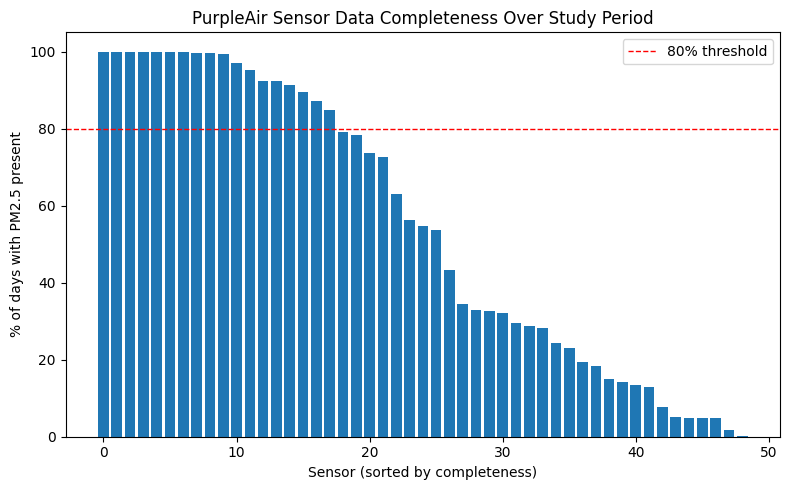

In [12]:
"""
Check how complete each PurpleAir sensor's record is across the full study
period -- i.e. what percentage of days each sensor actually has data for.

Works on either the raw merged dataset (purpleair_weather_by_sensor.csv,
which only has rows for days a sensor reported) or the already-balanced
panel (purpleair_weather_by_sensor_balanced.csv, which already has one row
per sensor per day). Either way, this reindexes onto the full date range
itself, so you get an apples-to-apples completeness number regardless of
which file you point it at.

Requirements: pip install pandas numpy matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
INPUT_PATH = "purpleair_weather_by_sensor.csv"  # or the raw file

TARGET_COL = "pm25_epa_corrected"
FEATURE_COLS = [
    "pm25_epa_corrected",
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean",
    "winddirection_10m_prevailing",
    "windgusts_10m_max",
]


# ------------------------------------------------------------------
# Reindex onto the full date range (a no-op if the input is already the
# balanced panel, necessary if you're checking the raw file instead).
# Accepts either a file path (str) or a DataFrame already in memory.
# ------------------------------------------------------------------
def load_and_reindex(data):
    if isinstance(data, str):
        data = pd.read_csv(data, parse_dates=["date"])
    else:
        data = data.copy()
        if not np.issubdtype(data["date"].dtype, np.datetime64):
            data["date"] = pd.to_datetime(data["date"])

    sensor_ids = sorted(data["sensor_index"].unique())
    full_dates = pd.date_range(data["date"].min(), data["date"].max(), freq="D")
    full_index = pd.MultiIndex.from_product(
        [sensor_ids, full_dates], names=["sensor_index", "date"]
    )
    panel = data.set_index(["sensor_index", "date"]).reindex(full_index).reset_index()
    return panel, sensor_ids, full_dates


# ------------------------------------------------------------------
# Per-sensor, per-column completeness
# ------------------------------------------------------------------
def compute_completeness(panel, cols):
    rows = []
    for sensor_index, group in panel.groupby("sensor_index"):
        row = {"sensor_index": sensor_index, "n_days_total": len(group)}
        for col in cols:
            row[f"{col}_pct_present"] = group[col].notna().mean()
        rows.append(row)
    report = pd.DataFrame(rows)
    return report.sort_values(f"{TARGET_COL}_pct_present", ascending=False)


def summarize(report):
    pct_col = f"{TARGET_COL}_pct_present"
    n_days = report["n_days_total"].iloc[0]
    print(f"\n{len(report)} sensors, {n_days} days in the study period\n")
    print("PM2.5 coverage distribution across sensors:")
    print(report[pct_col].describe().to_string())
    print()
    for threshold in [0.9, 0.7, 0.5, 0.3]:
        n_below = (report[pct_col] < threshold).sum()
        print(f"Sensors below {threshold:.0%} PM2.5 coverage: "
              f"{n_below} / {len(report)}")


# ------------------------------------------------------------------
# Bar chart, sorted worst-to-best, for a quick visual read
# ------------------------------------------------------------------
def plot_completeness(report, out_path="sensor_completeness.png"):
    pct_col = f"{TARGET_COL}_pct_present"
    sorted_report = report.sort_values(pct_col, ascending=False)

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_report) * 0.15), 5))
    ax.bar(range(len(sorted_report)), sorted_report[pct_col] * 100)
    ax.set_xlabel("Sensor (sorted by completeness)")
    ax.set_ylabel("% of days with PM2.5 present")
    ax.set_title("PurpleAir Sensor Data Completeness Over Study Period")
    ax.axhline(80, color="red", linestyle="--", linewidth=1, label="80% threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"\nSaved completeness chart to {out_path}")


def main(data=INPUT_PATH):
    panel, sensor_ids, full_dates = load_and_reindex(data)
    print(f"Study period: {full_dates.min().date()} to {full_dates.max().date()} "
          f"({len(full_dates)} days), {len(sensor_ids)} sensors")

    report = compute_completeness(panel, FEATURE_COLS)
    report.to_csv("sensor_completeness_report.csv", index=False)
    print("Saved sensor_completeness_report.csv "
          "(per-sensor, per-column completeness %)")

    summarize(report)
    plot_completeness(report)


if __name__ == "__main__":
    main()

In [13]:
df=pd.read_csv("purpleair_weather_by_sensor.csv" )

In [14]:
df

,time_stamp,humidity,temperature,pressure,pm2.5_atm,pm2.5_cf_1,sensor_index,date,pm25_epa_corrected,latitude,...,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,windgusts_10m_max,surface_pressure_mean,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing
0,1742342400,12.0,69.0,980.90,0.4,0.4,262441,2025-03-19,4.926,33.267300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1741910400,35.0,61.0,970.81,0.2,0.2,262441,2025-03-14,2.844,33.267300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1745193600,16.0,83.0,970.29,3.5,3.5,262441,2025-04-21,6.194,33.267300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1744156800,13.0,85.0,973.15,5.2,5.2,262441,2025-04-09,7.336,33.267300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1743638400,22.0,69.0,967.40,1.5,1.5,262441,2025-04-03,4.638,33.267300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20097,1753401600,5.0,100.0,944.65,1.5,1.5,260035,2025-07-25,6.100,33.638542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20098,1753660800,6.0,104.0,944.48,0.1,0.1,260035,2025-07-28,5.286,33.638542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20099,1753315200,6.0,100.0,946.39,3.3,3.3,260035,2025-07-24,6.950,33.638542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20100,1753142400,24.0,98.0,944.19,1.8,1.8,260035,2025-07-22,4.622,33.638542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
"""
Build one directed sensor network per day from the PurpleAir + Open-Meteo
dataset produced by purpleair_weather_pull.py.

NODES: every sensor in sensor_metadata.csv. The node SET is fixed across
every day in the dataset -- a sensor with no data on a given day still
appears as a node (features = NaN, has_data = False), it just has no
outgoing edges that day (see below). Only the edges, and the node feature
values, change day to day.

TARGET (per node, per day): PM2.5, EPA-humidity-corrected
PREDICTORS (per node, per day): temperature, humidity, precipitation,
    surface pressure, ET0, wind speed, wind direction, wind gust
    -- all pulled per-sensor from Open-Meteo, NOT from PurpleAir's own
    onboard temp/humidity sensors (those are unreliable, see the pull script).

EDGES: directed, i -> j, present only if distance(i, j) <= DIST_CUTOFF_KM.
Weight:

    w(i->j, t) = exp(-d_ij / sigma^2) * max(0, cos(theta_i->j - phi_i,t)) * W_i,t

    d_ij       = great-circle distance between sensor i and sensor j (km)
    theta_i->j = compass bearing FROM sensor i TO sensor j (0-360 deg, from N)
    phi_i,t    = direction wind is blowing TOWARD at sensor i on day t
    W_i,t      = wind speed at sensor i on day t

Physical intuition: an edge i -> j gets more weight when (a) i and j are
close together, (b) sensor i's wind is blowing roughly toward j rather than
away from it, and (c) sensor i's wind is strong. max(0, cos(...)) zeroes the
edge out entirely once the wind is blowing more than 90 degrees away from
j's bearing, rather than letting the weight go negative.

** WIND DIRECTION CONVENTION -- VERIFY THIS FOR ANY NEW DATA SOURCE **
Open-Meteo's `winddirection_10m` follows the standard meteorological
convention: direction the wind is blowing FROM, clockwise from north. This
script converts explicitly with `downwind_direction()` (FROM + 180 = TOWARD)
before using it in the edge weight. Some other sources (e.g. ocean current
data, some model outputs) report the direction flow is heading TOWARD
instead -- always confirm which convention a source uses before wiring it
into this formula, since it silently reverses every edge's meaning rather
than throwing an error.

Requirements: pip install networkx pandas numpy
"""

import pickle
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
DIST_CUTOFF_KM = 15.0   # max sensor separation allowed for a possible edge
SIGMA = 5.0              # decay scale (km) used in exp(-d / sigma^2)

TARGET_COL = "pm25_epa_corrected"

# Columns pulled onto each node for internal use (e.g. computing edge
# weights). Note winddirection_10m_prevailing is raw degrees -- it's needed
# in this form for the edge-weight trig, but raw degrees are a bad ML
# feature (circular discontinuity: 359 and 1 are numerically far apart but
# physically identical), so it is NOT included in ML_FEATURE_COLS below.
PREDICTOR_COLS = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean",
    "winddirection_10m_prevailing",
    "windgusts_10m_max",
]

# Columns actually exported as model features in export_tensors(). Wind
# speed is kept -- it has a direct local effect (dispersing/diluting PM2.5
# at the node itself) independent of the role it plays in the edges. Wind
# direction is re-encoded as sin/cos so the model sees a continuous
# representation instead of a wraparound angle.
ML_FEATURE_COLS = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "surface_pressure_mean",
    "et0_fao_evapotranspiration",
    "windspeed_10m_mean",
    "wind_dir_sin",
    "wind_dir_cos",
    "windgusts_10m_max",
]

EARTH_RADIUS_KM = 6371.0


# ------------------------------------------------------------------
# Geometry: pairwise distance + bearing between all sensor pairs.
# Computed once -- sensor locations don't change day to day.
# ------------------------------------------------------------------
def haversine_distance_matrix(lats, lons):
    lat = np.radians(lats)[:, None]
    lat_t = lat.T
    lon = np.radians(lons)[:, None]
    lon_t = lon.T

    dlat = lat_t - lat
    dlon = lon_t - lon
    a = np.sin(dlat / 2) ** 2 + np.cos(lat) * np.cos(lat_t) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return EARTH_RADIUS_KM * c


def bearing_matrix(lats, lons):
    """Initial compass bearing (degrees, 0-360, clockwise from north) from
    each point i to each point j. bearing_matrix[i, j] = bearing FROM i TO j."""
    lat = np.radians(lats)[:, None]
    lat_t = lat.T
    lon = np.radians(lons)[:, None]
    lon_t = lon.T

    dlon = lon_t - lon
    y = np.sin(dlon) * np.cos(lat_t)
    x = np.cos(lat) * np.sin(lat_t) - np.sin(lat) * np.cos(lat_t) * np.cos(dlon)
    theta = np.degrees(np.arctan2(y, x))
    return (theta + 360) % 360


def downwind_direction(from_direction_deg):
    """Convert a meteorological 'blowing FROM' direction to the direction
    the wind is blowing TOWARD (i.e. the direction pollution would advect)."""
    return (from_direction_deg + 180) % 360


# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
def load_data(sensor_metadata_path, sensor_weather_path):
    sensors = pd.read_csv(sensor_metadata_path)
    sensors = sensors.sort_values("sensor_index").reset_index(drop=True)

    data = pd.read_csv(sensor_weather_path, parse_dates=["date"])
    return sensors, data


# ------------------------------------------------------------------
# Build one day's directed graph
# ------------------------------------------------------------------
def build_daily_graph(date, day_df, dist_km, bearing_deg, node_ids):
    G = nx.DiGraph()
    day_df = day_df.set_index("sensor_index")

    # Add every sensor as a node every day, even with no data today, so the
    # node set is identical across all daily graphs.
    for sensor_index in node_ids:
        if sensor_index in day_df.index:
            row = day_df.loc[sensor_index]
            target = row.get(TARGET_COL, np.nan)
            predictors = {c: row.get(c, np.nan) for c in PREDICTOR_COLS}
            has_data = not pd.isna(target)
        else:
            target = np.nan
            predictors = {c: np.nan for c in PREDICTOR_COLS}
            has_data = False

        G.add_node(sensor_index, target=target, has_data=has_data, **predictors)

        # Derived sin/cos encoding of wind direction for ML use — avoids the
        # circular-degree discontinuity in the raw column.
        raw_dir = predictors.get("winddirection_10m_prevailing", np.nan)
        if pd.isna(raw_dir):
            G.nodes[sensor_index]["wind_dir_sin"] = np.nan
            G.nodes[sensor_index]["wind_dir_cos"] = np.nan
        else:
            rad = np.radians(raw_dir)
            G.nodes[sensor_index]["wind_dir_sin"] = float(np.sin(rad))
            G.nodes[sensor_index]["wind_dir_cos"] = float(np.cos(rad))

    # Per-node wind speed and downwind (blowing TOWARD) direction, used below.
    wind_speed = {}
    downwind_dir = {}
    for sensor_index in node_ids:
        node = G.nodes[sensor_index]
        w = node.get("windspeed_10m_mean", np.nan)
        d = node.get("winddirection_10m_prevailing", np.nan)
        wind_speed[sensor_index] = w
        downwind_dir[sensor_index] = np.nan if pd.isna(d) else downwind_direction(d)

    n = len(node_ids)
    for i in range(n):
        src = node_ids[i]
        phi_i = downwind_dir[src]
        w_i = wind_speed[src]

        # No wind reading for this source node today -> it can't push
        # pollution anywhere; it simply has no outgoing edges today.
        if pd.isna(phi_i) or pd.isna(w_i):
            continue

        for j in range(n):
            if i == j:
                continue
            d_ij = dist_km[i, j]
            if d_ij > DIST_CUTOFF_KM:
                continue

            theta_ij = bearing_deg[i, j]
            directional_term = max(0.0, np.cos(np.radians(theta_ij - phi_i)))
            if directional_term == 0.0:
                continue  # wind blowing away from j -- no edge

            weight = np.exp(-d_ij / SIGMA ** 2) * directional_term * w_i
            if weight > 0:
                G.add_edge(src, node_ids[j], weight=float(weight), distance_km=float(d_ij))

    G.graph["date"] = str(date.date()) if hasattr(date, "date") else str(date)
    return G


# ------------------------------------------------------------------
# Build all daily graphs
# ------------------------------------------------------------------
def build_all_daily_graphs(sensors, data):
    node_ids = sensors["sensor_index"].tolist()
    lats = sensors["latitude"].to_numpy()
    lons = sensors["longitude"].to_numpy()

    dist_km = haversine_distance_matrix(lats, lons)
    bearing_deg = bearing_matrix(lats, lons)

    graphs = {}
    for date, day_df in data.groupby("date"):
        G = build_daily_graph(date, day_df, dist_km, bearing_deg, node_ids)
        graphs[str(date.date())] = G
        print(f"{date.date()}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    return graphs


# ------------------------------------------------------------------
# Optional: export as dense tensors for GNN training (fixed node order,
# so these stack cleanly across days).
# ------------------------------------------------------------------
def export_tensors(graphs, node_ids, out_path="daily_networks_tensors.npz"):
    dates = sorted(graphs.keys())
    n = len(node_ids)
    idx_of = {sid: k for k, sid in enumerate(node_ids)}

    X = np.full((len(dates), n, 1 + len(ML_FEATURE_COLS)), np.nan)  # target + predictors
    A = np.zeros((len(dates), n, n))

    for t, date in enumerate(dates):
        G = graphs[date]
        for sensor_index, attrs in G.nodes(data=True):
            k = idx_of[sensor_index]
            X[t, k, 0] = attrs["target"]
            for f_i, col in enumerate(ML_FEATURE_COLS):
                X[t, k, 1 + f_i] = attrs[col]
        for u, v, attrs in G.edges(data=True):
            A[t, idx_of[u], idx_of[v]] = attrs["weight"]

    np.savez_compressed(
        out_path,
        node_ids=np.array(node_ids),
        dates=np.array(dates),
        feature_names=np.array([TARGET_COL] + ML_FEATURE_COLS),
        X=X,   # shape (T, N, 1 + n_features) -- X[..., 0] is the target
        A=A,   # shape (T, N, N) -- A[t, i, j] is edge weight i -> j on day t
    )
    print(f"Saved tensors to {out_path}: X{X.shape}, A{A.shape}")


def main():
    sensors, data = load_data("sensor_metadata.csv", "purpleair_weather_by_sensor.csv")
    graphs = build_all_daily_graphs(sensors, data)

    with open("daily_networks.pkl", "wb") as f:
        pickle.dump(graphs, f)
    print(f"Saved {len(graphs)} daily graphs to daily_networks.pkl")

    export_tensors(graphs, sensors["sensor_index"].tolist())


if __name__ == "__main__":
    main()